<a href="https://colab.research.google.com/github/akovacs/dithering-experiments/blob/main/blue_noise_optimize_fft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import jax.numpy as jnp
import numpy as np
import jax
import matplotlib.pyplot as plt

In [2]:
def spectrum(m):
  # Put the constant term in the center
  return jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(m)))

def blue_noise_loss(m, SIZE):
  # squared deviation from low frequency in the center
  CUTOFF_FREQ = 0.7
  low_freq_weights = jnp.maximum(CUTOFF_FREQ -jnp.outer(jnp.square(np.linspace(1,-1,SIZE)),jnp.ones(SIZE))-jnp.outer(np.ones(SIZE), jnp.square(jnp.linspace(1,-1,SIZE))), 0.0) / CUTOFF_FREQ
  return jnp.sum(low_freq_weights * low_freq_weights * jnp.square(spectrum(m))) / (SIZE*SIZE)

def histogram_loss(m, SIZE):
  # squared difference of sorted values as compared to the reference distribution
  reference_range = jnp.linspace(-1, 1, SIZE*SIZE)
  return jnp.sum(jnp.square(jnp.sort(m.flatten()) - reference_range))

def spectrum_uniformity_loss(m, SIZE):
  # a 2d laplacian as well as a sumple squared horizontal and vertical gradient
  s = spectrum(m)
  laplacian = (-4.0 * s + jnp.roll(s, 1, axis=1) + jnp.roll(s, -1, axis=1) + jnp.roll(s, 1, axis=0) + jnp.roll(s, -1, axis=0))/5.0
  g_x = (s - jnp.roll(s, 1, axis=0)) / 2.0
  g_y = (s - jnp.roll(s, 1, axis=1)) / 2.0
  return (jnp.sum(jnp.square(laplacian)) + jnp.sum(jnp.square(g_x)) + jnp.sum(jnp.square(g_y))) / (SIZE*SIZE)

def full_loss(m, loss_component_1 = 1.0, loss_component_2 = 1.0, loss_component_3 = 1.0):
  spectral_loss = blue_noise_loss(m, SIZE) * loss_component_3
  range_loss = histogram_loss(m, SIZE) * loss_component_2
  uniformity_loss = spectrum_uniformity_loss(m, SIZE) * loss_component_1
  return 0.01 * uniformity_loss + 2.2 * range_loss + 0.1 * spectral_loss

grad = jax.jit(jax.grad(full_loss))
loss = jax.jit(full_loss)


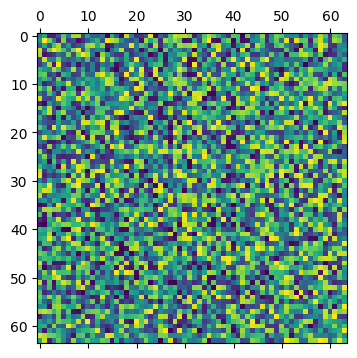

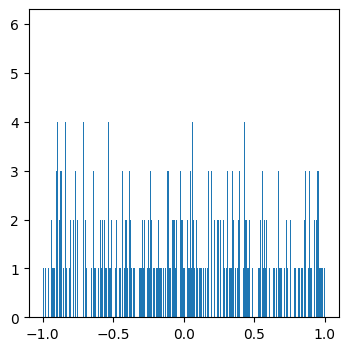

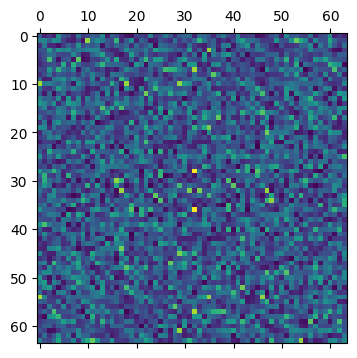

5.291975 0.35868305 0.35868305 30.19165
4.9015894 2.1415184 2.1415184 28.92808 0.0
0.061469555 0.00037500708 0.00037500708 0.11527489 5.0
0.056266896 0.0012145776 0.0012145776 0.09654868 10.0
0.05379057 0.00019842028 0.00019842028 0.08551244 15.0
0.05230342 8.04486e-05 8.04486e-05 0.07964958 20.0
0.050163526 0.00017692319 0.00017692319 0.07481037 25.0
0.0491298 0.00015762707 0.00015762707 0.07197369 30.0
0.048511628 0.00013334073 0.00013334073 0.06938919 35.0
0.048171252 2.0110405e-05 2.0110405e-05 0.067234136 40.0
0.047433615 0.0006678008 0.0006678008 0.06617592 45.0
0.046810415 0.00011686643 0.00011686643 0.0643772 50.0
0.046476297 8.448915e-05 8.448915e-05 0.06314405 55.00000000000001
0.04599834 0.004602663 0.004602663 0.067065164 60.0
0.04566488 0.0001832568 0.0001832568 0.061193883 65.0
0.04551669 5.9873688e-05 5.9873688e-05 0.06036274 70.0
0.04540058 0.0005414901 0.0005414901 0.059924547 75.0
0.045251243 9.9328245e-05 9.9328245e-05 0.058628194 80.0
0.04531139 0.00010105748 0.0001

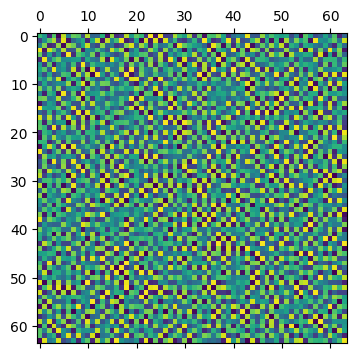

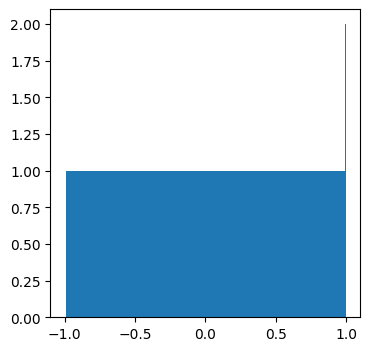

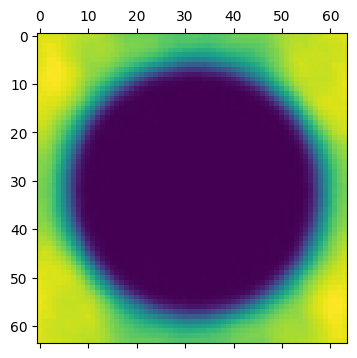

In [3]:
SIZE=64
noise_mat = jnp.array((np.random.rand(SIZE,SIZE) - 0.5) * 2.0, dtype='float32')
noise_orig = noise_mat.copy()

def plot_results(m, SIZE):
  plt.rcParams['figure.figsize']=4,4
  plt.matshow(m)
  plt.show()
  plt.hist(m.flatten(), bins=SIZE*SIZE)
  plt.show()
  plt.matshow(jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(m))))
  plt.show()
plot_results(noise_mat, SIZE)
print(loss(noise_mat, 1.0, 0.0, 0.0), loss(noise_mat, 0.0, 1.0, 0.0), loss(noise_mat, 0.0, 1.0, 0.0), loss(noise_mat, 1.0, 1.0, 1.0))

N_ITER = 100000
for i in range(N_ITER):
  # Randomize the loss components relative weights and "stochasticize" it.
  grads = grad(noise_mat, np.random.rand(), np.random.rand(), np.random.rand())
  noise_mat = noise_mat - 0.7 * grads
  # Once every 5k iterations, print the loss for verification.
  if i % 5000 == 0:
    print(loss(noise_mat, 1.0, 0.0, 0.0), loss(noise_mat, 0.0, 1.0, 0.0), loss(noise_mat, 0.0, 1.0, 0.0), loss(noise_mat, 1.0, 1.0, 1.0), i / N_ITER * 100.0)
print(loss(noise_mat, 1.0, 0.0, 0.0), loss(noise_mat, 0.0, 1.0, 0.0), loss(noise_mat, 0.0, 1.0, 0.0), loss(noise_mat, 1.0, 1.0, 1.0))
# fine tune the histogram
for i in range(10):
  grads = grad(noise_mat, 0.0, np.random.rand(), 0.0)
  noise_mat = noise_mat - 0.1 * grads
plot_results(noise_mat, SIZE)

In [10]:
import cv2
import scipy.ndimage
import urllib.request
from google.colab import files
import numpy as np

# Get the test image.
# urllib.request.urlretrieve('https://i.imgur.com/bFQRi91.png', filename='kodim14.png')
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
img_array = np.frombuffer(uploaded[file_name], np.uint8)
test_img = cv2.imdecode(img_array, cv2.IMREAD_COLOR) / 255.0
#test_img = cv2.imread('kodim14.png')[:,:,(2,1,0)] / 255.0


Saving BlackGreyWhiteGradient-350x350-5.png to BlackGreyWhiteGradient-350x350-5.png


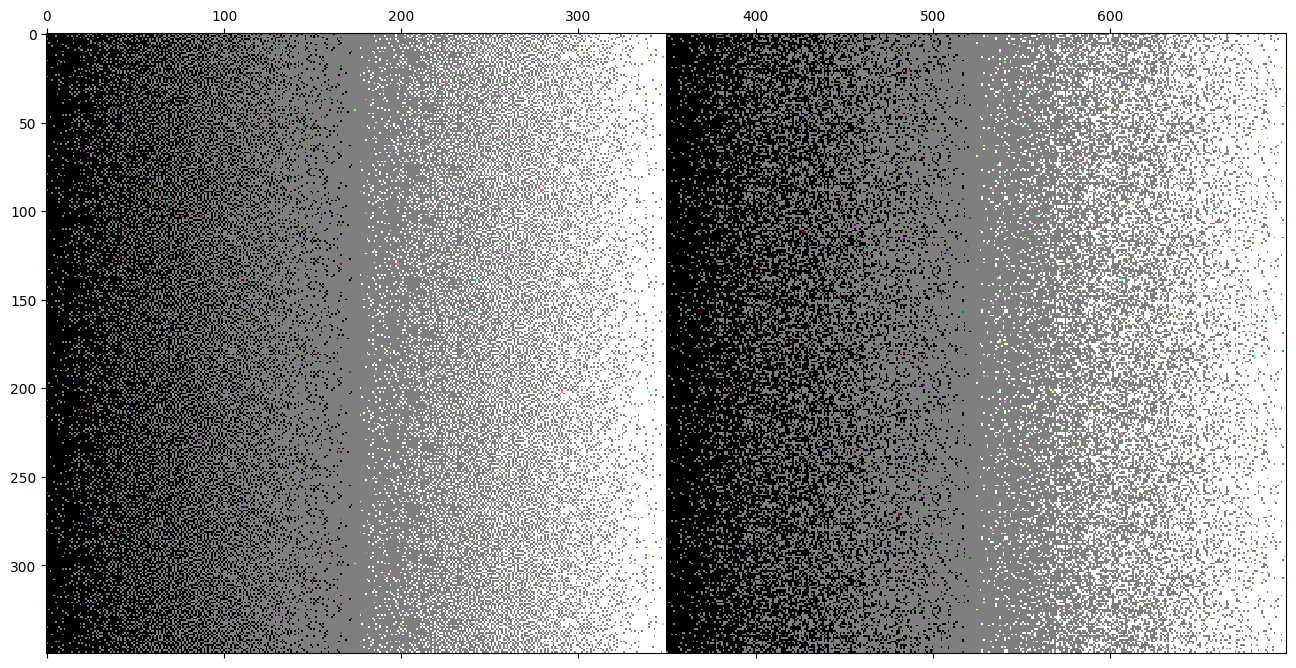

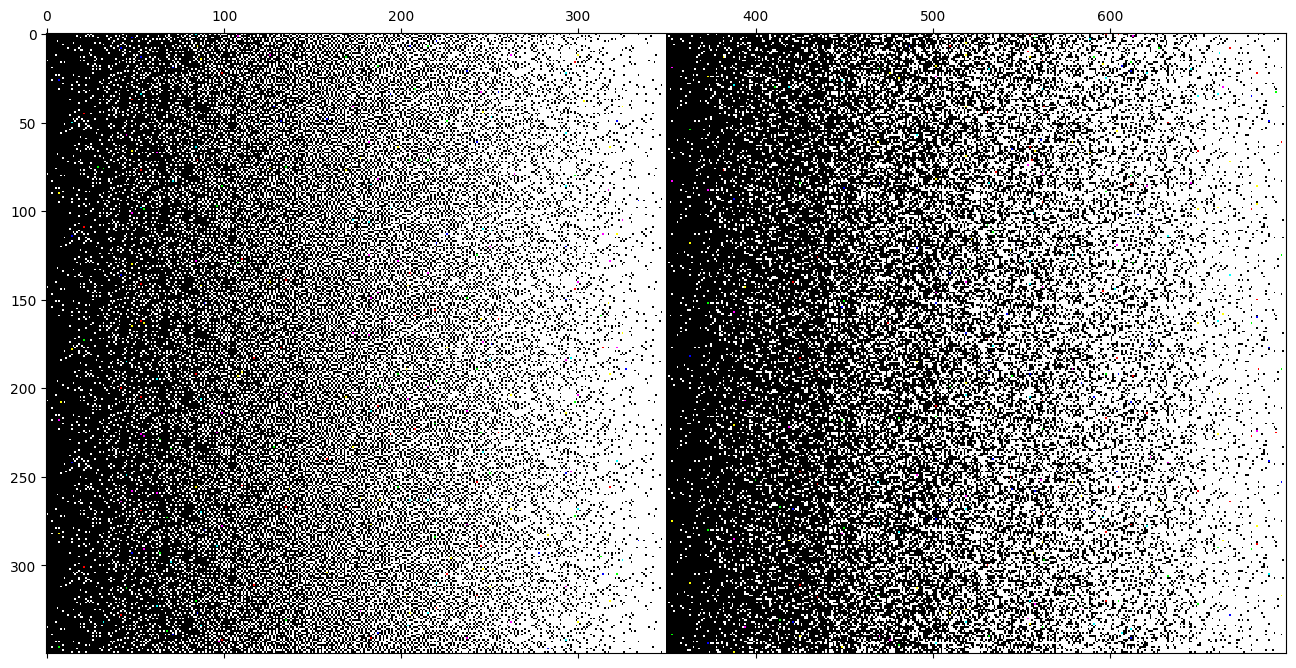

In [11]:
noise_wrapped = jnp.tile(noise_mat, reps=[10,10])[0:test_img.shape[0], 0:test_img.shape[1]]
noise_wrapped_3d = jnp.stack((noise_wrapped,noise_wrapped,noise_wrapped), axis=-1)
noise_wrapped_orig = jnp.tile(noise_orig, reps=[10,10])[0:test_img.shape[0], 0:test_img.shape[1]]
noise_wrapped_orig_3d = jnp.stack((noise_wrapped_orig,noise_wrapped_orig,noise_wrapped_orig), axis=-1)

plt.rcParams['figure.figsize']=15,15

# 2 bits
dither_scale = 2.0
dithered_blue = 1.0/dither_scale*np.round(dither_scale*test_img+0.5*noise_wrapped_3d)
dithered_white = 1.0/dither_scale*np.round(dither_scale*test_img+0.5*noise_wrapped_orig_3d)

plt.matshow(np.hstack((dithered_blue, dithered_white)))
plt.show()

# 1 bit
dither_scale = 1.0
dithered_blue = 1.0/dither_scale*np.round(dither_scale*test_img+0.5*noise_wrapped_3d)
dithered_white = 1.0/dither_scale*np.round(dither_scale*test_img+0.5*noise_wrapped_orig_3d)

plt.matshow(np.hstack((dithered_blue, dithered_white)))
plt.show()
